### 5.1 회귀(Regression)
: 데이터 값이 일정한 값으로 돌아가려는 경향을 이용하여 여러 개의 독립 변수(Feature)와 한 개의 종속 변수(Target) 간의 상관관계를 모델링하는 기법

- 핵심 → 최적의 회귀 계수
- 연속형 숫자 값의 지도 학습

| 독립 변수 개수 | 회귀 계수 결합 |
| --- | --- |
| 1개 : 단일 회귀 | 선형 : 선형 회귀 |
| 여러 개 : 다중 회귀 | 비선형 : 비선형 회귀 |
- 선형 회귀 : 실제 값과 예측 값의 차이를 최소화 하는 직선형 회귀선 최적화 방식
    - 일반 선형 회귀 : RSS 최소화 할 수 있도록 회귀 계수 최적화
    - 릿지 / 라쏘 / 엘라스틱넷 / 로지스틱 회귀

### 5.2 단순 선형 회귀
: 독립 변수와 종속 변수 모두 1개인 선형 회귀

<aside>
    
**용어 정리**

- 실제 값 : 데이터에서 관측한 값
    
- 모델(예측 값) : 모델이 예측하는 값

- 회귀 계수(intercept) : w변수
- 잔차 : 실제 값과 회귀 모델의 차이에 따른 오류 값 → 작을 수록 좋음

- RSS(Residual Sum of Square) : 오류 값의 제곱을 구해서 더하는 방식
    - 비용함수 / 손실 함수

- MSE(Mean Squared Error) : 평균 오차 제곱으로 데이터 크기와 무관

- RMSE(Root Mean Squared Error) : 오차 평균 크기를 실제 단위로 환산
</aside>

### 5.3 경사 하강법Gradient Descent
: 점진적으로 반복하여 W파라미터를 업데이트하며 오류 값이 최소인 회귀 계수를 구하는 방식

<aside>

**방향성**

- 오류 값이 작아지는 방향으로 W 파라미터 보정
- 미분된 1차 함수의 기울기가 감소하지 않는 지점
1. 임의의 회귀 계수로 첫 비용 함수 값 계산
2. 업데이트 후 다시 비용 함수 값 계산(최소까지 반복)
       
</aside>

**관련 넘파이 API**

- np.dot( X, w1.T ) : 내적 연산 수행
    - cf. w1*x : 같은 의미지만 원소별 곱하기 수행

**실제값을 Y=4X+6 시뮬레이션하는 데이터 값 생성**

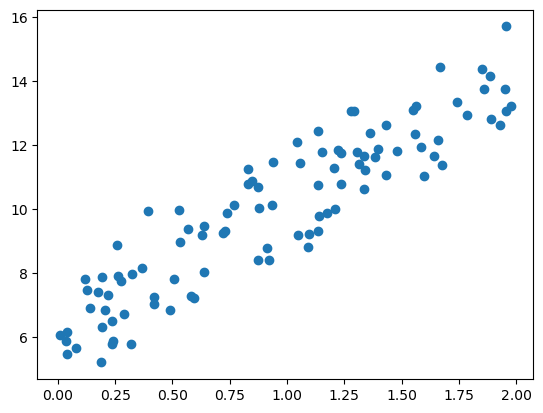

In [8]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(0)
# y = 4X + 6 식을 근사(w1=4, w0=6). random 값은 Noise를 위해 만듬
X = 2 * np.random.rand(100,1)  # 난수 범위를 0~2로 만들어 더 다양한 데이터 구간을 보여주기 위해 2를 곱함.
y = 6 +4 * X+ np.random.randn(100,1)  # random은 노이즈

# X, y 데이터 셋 scatter plot으로 시각화
plt.scatter(X, y)

In [9]:
X.shape, y.shape

((100, 1), (100, 1))

**일반 경사 하강법 관련 함수 코드**

In [10]:
# 비용함수(MSE) 구하기
def get_cost(y, y_pred):
	N = len(y)
	cost = np.sum(np.square(y - y_pred))/N
	return cost

In [11]:
# 회귀 계수 최소화 업데이트 함수(1회)
def get_weight_updates(w1, w0, X, y, learning_rate=0.01):
    N = len(y)
    # w1, w0 업데이트 값 초기화
    w1_update = np.zeros_like(w1)
    w0_update = np.zeros_like(w0)
    
    # 현재 파라미터로 예측값 계산
    y_pred = np.dot(X, w1.T) + w0
    diff = y-y_pred  #오류 값(잔차)
   
    w0_factors = np.ones((N,1))  # w0 업데이트용 상수 벡터

		# 기울기 계산(편미분 결과)
    w1_update = -(2/N)*learning_rate*(np.dot(X.T, diff))
    w0_update = -(2/N)*learning_rate*(np.dot(w0_factors.T, diff))    
    
    return w1_update, w0_update

In [12]:
w0 = np.zeros((1,1))
w1 = np.zeros((1,1))
y_pred = np.dot(X, w1.T) + w0
diff = y-y_pred
print(diff.shape)
w0_factors = np.ones((100,1))
w1_update = -(2/100)*0.01*(np.dot(X.T, diff))
w0_update = -(2/100)*0.01*(np.dot(w0_factors.T, diff))   
print(w1_update.shape, w0_update.shape)
w1, w0

(100, 1)
(1, 1) (1, 1)


(array([[0.]]), array([[0.]]))

In [13]:
# 경사 하강 수행
def gradient_descent_steps(X, y, iters=10000):
    # w0와 w1을 모두 0으로 초기화
    w0 = np.zeros((1,1))
    w1 = np.zeros((1,1))
    
    # get_weight_updates() 호출하여 w1, w0 업데이트 수행. 
    for ind in range(iters):
        w1_update, w0_update = get_weight_updates(w1, w0, X, y, learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update
              
    return w1, w0

**예측 오차 비용을 계산을 수행하는 함수 생성 및 경사 하강법 수행**

In [14]:
def get_cost(y, y_pred):
    N = len(y) 
    cost = np.sum(np.square(y - y_pred))/N
    return cost

w1, w0 = gradient_descent_steps(X, y, iters=1000)
print("w1:{0:.3f} w0:{1:.3f}".format(w1[0,0], w0[0,0]))
y_pred = w1[0,0] * X + w0
print('Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))

w1:4.022 w0:6.162
Gradient Descent Total Cost:0.9935


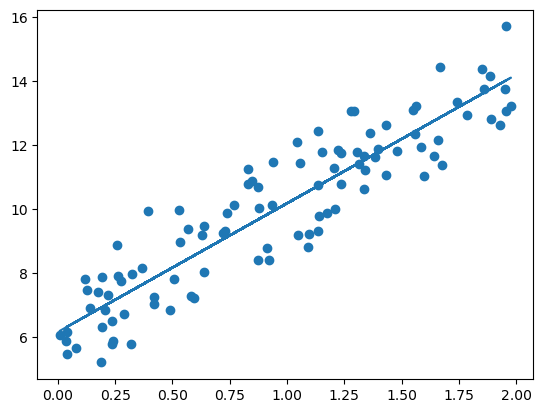

In [15]:
plt.scatter(X, y)
plt.plot(X,y_pred)

**확률적 경사 하강법(Stochastic Gradient Descent)**
    : 일부 데이터만을 활용해서 빠르게 최적의 비용함수를 도출

In [16]:
def stochastic_gradient_descent_steps(X, y, batch_size=10, iters=1000):
    w0 = np.zeros((1,1))
    w1 = np.zeros((1,1))
    prev_cost = 100000
    iter_index =0
    
    for ind in range(iters):
        np.random.seed(ind)
        
        # sample 추출
        stochastic_random_index = np.random.permutation(X.shape[0])
        sample_X = X[stochastic_random_index[0:batch_size]]
        sample_y = y[stochastic_random_index[0:batch_size]]
        
        # sample기반 w1_update, w0_update 계산 후 업데이트
        w1_update, w0_update = get_weight_updates(w1, w0, sample_X, sample_y, learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update
    
    return w1, w0

In [17]:
w1, w0 = stochastic_gradient_descent_steps(X, y, iters=1000)
print("w1:",round(w1[0,0],3),"w0:",round(w0[0,0],3))
y_pred = w1[0,0] * X + w0
print('Stochastic Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))

w1: 4.028 w0: 6.156
Stochastic Gradient Descent Total Cost:0.9937


### 4. 사이킷런 LinearRegression

: RSS를 최소화해 OLS(Ordinary Least Squares) 추정 방식으로 구현한 클래스

- 다중 공선성(multi-collinearity) : 피처 독립성에 많은 영향을 받음

<aside>

**관련 sklearn API**

- 입력 파라미터
    - fit_intercept : 절편을 계산할 지 여부를 지정; default = True
    - normalize : 회귀 수행 전 입력 데이터 세트 정규화; default = False, fit_intercept = False 시 사용 X
- 속성
    - coef_ : 회귀 계수가 배열로 저장되는 속성
    - intercpet_ : intercpet 값
</aside>

**회귀 성능 평가 지표**

cf. r2 빼고 모두 음수 곱 → 작은 오류 값을 더 큰 숫자로 인식 ; 회귀는 작을 수록 더 좋기 때문에

| **평가 지표** | 설명 | API |
| --- | --- | --- |
| MAE | 실제값 - 예측값을 절댓값으로 변환해 평균 | metrics.mean_absolute_error |
| MSE | 실제값 - 예측값을 제곱해 평균 | metrics.mean_squared_error |
| RMSE | MSE에 루트를 씌운 값 | metrics.mean_squared_error ; squared = False |
| MSLE | MSE에 로그를 적용한 값 | metrics.mean_squared_log_error |
| RMSLE | RMSE에 로그를 적용한 값 | metrics.mean_squared_log_error |
| R^2 | 실제값의 분산 대비 예측값의 분산 비율 | metrics.r2_score |

cf2. load_boston을 해당 버전에서 사용할 수 없어서 유사한 데이터셋인 fetch_california_housing을 쓴다.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# 캘리포니아 주택 데이터셋 로드
cali = fetch_california_housing()

# DataFrame 변환
caliDF = pd.DataFrame(cali.data, columns=cali.feature_names)

# target은 집값의 중위수, PRICE 컬럼으로 추가
caliDF['PRICE'] = cali.target

print('California Housing 데이터셋 크기 :', caliDF.shape)
caliDF.head()

California Housing 데이터셋 크기 : (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


* MedInc : 블록 그룹(block group) 내 중위소득(median income)
* HouseAge : 블록 그룹 내 주택의 중위 연령(median house age)
* AveRooms : 가구당 평균 방 개수
* AveBedrms : 가구당 평균 침실 개수
* Population : 블록 그룹의 총 인구 수
* AveOccup : 가구당 평균 거주 인원 수
* Latitude : 블록 그룹의 위도
* Longitude : 블록 그룹의 경도
* PRICE(target) : 해당 지역의 주택 가격 중위수(단위 : 1000,000$)

* 각 컬럼별로 주택가격에 미치는 영향도를 조사

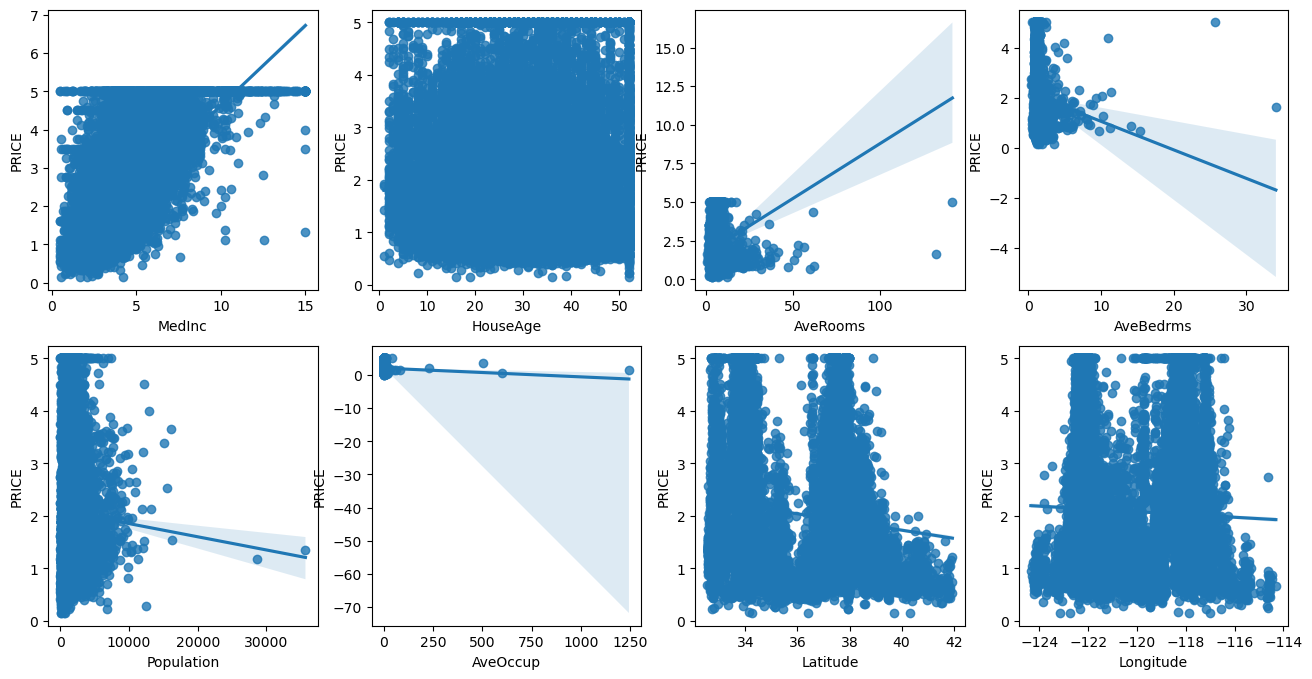

In [14]:
# 2개의 행과 4개의 열을 가진 subplots를 이용. axs는 4x2개의 ax를 가짐.
fig, axs = plt.subplots(figsize=(16,8) , ncols=4 , nrows=2)
lm_features = ['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','Latitude','Longitude']

for i , feature in enumerate(lm_features):
    row = int(i/4)
    col = i%4
    # 시본의 regplot을 이용해 산점도와 선형 회귀 직선을 함께 표현
    sns.regplot(x=feature , y='PRICE',data=caliDF , ax=axs[row][col])

fig1 = plt.gcf()
fig1.savefig('p322_california.tif', format='tif', dpi=300, bbox_inches='tight')

**학습과 테스트 데이터 세트로 분리하고 학습/예측/평가 수행**

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 타깃과 피처 분리
y_target = caliDF['PRICE']
X_data = caliDF.drop(['PRICE'], axis=1, inplace=False)

# 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_target, test_size=0.3, random_state=156
)

# 선형 회귀 모델 학습
lr = LinearRegression()
lr.fit(X_train, y_train)

# 예측
y_preds = lr.predict(X_test)

# 평가 지표 계산
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print('MSE : {0:.3f} , RMSE : {1:.3f}'.format(mse, rmse))
print('Variance score (R^2) : {0:.3f}'.format(r2_score(y_test, y_preds)))

MSE : 0.543 , RMSE : 0.737
Variance score (R^2) : 0.595


In [16]:
print('절편 값:',lr.intercept_)
print('회귀 계수값:', np.round(lr.coef_, 1))

절편 값: -37.239053052941564
회귀 계수값: [ 0.4  0.  -0.1  0.6 -0.  -0.  -0.4 -0.4]


In [17]:
# 회귀 계수를 큰 값 순으로 정렬하기 위해 Series로 생성. index가 칼럼명에 유의
coeff = pd.Series(data=np.round(lr.coef_, 1), index=X_data.columns )
coeff.sort_values(ascending=False)

AveBedrms     0.6
MedInc        0.4
HouseAge      0.0
Population   -0.0
AveOccup     -0.0
AveRooms     -0.1
Latitude     -0.4
Longitude    -0.4
dtype: float64

In [18]:
from sklearn.model_selection import cross_val_score

# 타깃과 피처 분리
y_target = caliDF['PRICE']
X_data = caliDF.drop(['PRICE'], axis=1, inplace=False)

# 선형 회귀 모델
lr = LinearRegression()

# 5-Fold 교차 검증으로 MSE 계산 후 RMSE 변환
neg_mse_scores = cross_val_score(lr, X_data, y_target,
                                 scoring="neg_mean_squared_error", cv=5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

# 결과 출력
print('5 folds 의 개별 Negative MSE scores:', np.round(neg_mse_scores, 2))
print('5 folds 의 개별 RMSE scores:', np.round(rmse_scores, 2))
print('5 folds 의 평균 RMSE: {0:.3f}'.format(avg_rmse))

5 folds 의 개별 Negative MSE scores: [-0.48 -0.62 -0.65 -0.54 -0.49]
5 folds 의 개별 RMSE scores: [0.7  0.79 0.8  0.74 0.7 ]
5 folds 의 평균 RMSE: 0.746


### 5. 다항 회귀와 과적합 / 과소적합

<aside>

**용어 정리**

- 다항 회귀(Polynomial Regression) : 독립 변수가 다항식으로 표현된 선형 회귀
    - 곡선으로 더 복잡한 데이터 설명 가능
- 과적합(Overfitting) : 모델이 학습 데이터에 너무 맞춰진 상태
    - 차수 높게 설정 → MSE 높아짐
- 과소적합(Underfitting) : 모델이 단순해서 패턴을 제대로 설명하지 못하는 상태
    - 차수 낮게 설정 → MSE 낮아짐
- 편향 - 분산 트레이드오프(Bias - Variance Trade Off)    
</aside>

**관련 sklearn API**

- PolynomialFeatures
    
    : 입력 데이터를 다항식으로 변환하는 클래스
    
    - fit_transform( X ) : 원래 데이터를 다항식 형태로 변환
    
    → 그 후 LinearRegression을 이용해 회귀 계수 학습

PolynomialFeatures 클래스로 다항식 변환

In [19]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# 다항식으로 변환한 단항식 생성, [[0,1],[2,3]]의 2X2 행렬 생성
X = np.arange(4).reshape(2,2)
print('일차 단항식 계수 feature:\n',X )

# degree = 2 인 2차 다항식으로 변환하기 위해 PolynomialFeatures를 이용하여 변환
poly = PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr = poly.transform(X)
print('변환된 2차 다항식 계수 feature:\n', poly_ftr)


일차 단항식 계수 feature:
 [[0 1]
 [2 3]]
변환된 2차 다항식 계수 feature:
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


3차 다항식 결정값을 구하는 함수 polynomial_func(X) 생성. 즉 회귀식은 결정값 y = 1+ 2x_1 + 3x_1^2 + 4x_2^3 

In [20]:
def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
    print(X[:, 0])
    print(X[:, 1])
    return y

X = np.arange(0,4).reshape(2,2)

print('일차 단항식 계수 feature: \n' ,X)
y = polynomial_func(X)
print('삼차 다항식 결정값: \n', y)

일차 단항식 계수 feature: 
 [[0 1]
 [2 3]]
[0 2]
[1 3]
삼차 다항식 결정값: 
 [  5 125]


3차 다항식 계수의 피처값과 3차 다항식 결정값으로 학습

In [21]:
# 3 차 다항식 변환 
poly_ftr = PolynomialFeatures(degree=3).fit_transform(X)
print('3차 다항식 계수 feature: \n',poly_ftr)

# Linear Regression에 3차 다항식 계수 feature와 3차 다항식 결정값으로 학습 후 회귀 계수 확인
model = LinearRegression()
model.fit(poly_ftr,y)
print('Polynomial 회귀 계수\n' , np.round(model.coef_, 2))
print('Polynomial 회귀 Shape :', model.coef_.shape)

3차 다항식 계수 feature: 
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
Polynomial 회귀 계수
 [-0.    0.18  0.18  0.36  0.54  0.72  0.72  1.08  1.62  2.34]
Polynomial 회귀 Shape : (10,)


**사이킷런 파이프라인(Pipeline)을 이용하여 3차 다항회귀 학습**  

사이킷런의 Pipeline 객체는 Feature 엔지니어링 변환과 모델 학습/예측을 순차적으로 결합해줍니다. 

In [22]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3 
    return y

# Pipeline 객체로 Streamline 하게 Polynomial Feature변환과 Linear Regression을 연결
model = Pipeline([('poly', PolynomialFeatures(degree=3)),
                  ('linear', LinearRegression())])
X = np.arange(4).reshape(2,2)
y = polynomial_func(X)

model = model.fit(X, y)
print('Polynomial 회귀 계수\n', np.round(model.named_steps['linear'].coef_, 2))


Polynomial 회귀 계수
 [-0.    0.18  0.18  0.36  0.54  0.72  0.72  1.08  1.62  2.34]


### 다항 회귀를 이용한 과소적합 및 과적합 이해

**cosine 곡선에 약간의 Noise 변동값을 더하여 실제값 곡선을 만듬**

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
%matplotlib inline

# 임의의 값으로 구성된 X값에 대해 코사인 변환 값을 반환.
def true_fun(X):
    return np.cos(1.5 * np.pi * X)

# X는 0부터 1까지 30개의 임의의 값을 순서대로 샘플링한 데이터입니다.
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))

# y 값은 코사인 기반의 true_fun()에서 약간의 노이즈 변동 값을 더한 값입니다.
y = true_fun(X) + np.random.randn(n_samples) * 0.1

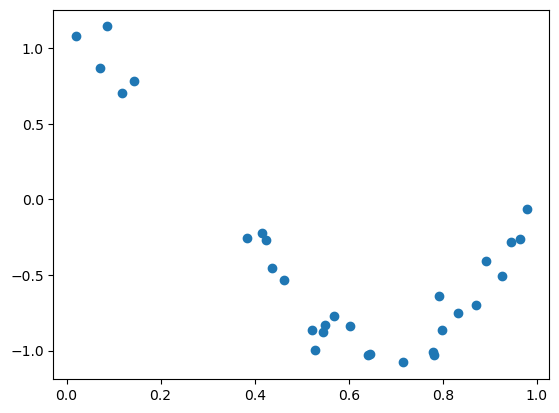

In [24]:
plt.scatter(X, y)


Degree 1 회귀 계수는 [-1.61] 입니다.
Degree 1 MSE 는 0.40772896250986845 입니다.

Degree 4 회귀 계수는 [  0.47 -17.79  23.59  -7.26] 입니다.
Degree 4 MSE 는 0.04320874987231737 입니다.

Degree 15 회귀 계수는 [-2.98293000e+03  1.03899370e+05 -1.87416114e+06  2.03716252e+07
 -1.44873341e+08  7.09315818e+08 -2.47066009e+09  6.24561742e+09
 -1.15676664e+10  1.56895176e+10 -1.54006289e+10  1.06457467e+10
 -4.91378551e+09  1.35919950e+09 -1.70381195e+08] 입니다.
Degree 15 MSE 는 182618860.9149443 입니다.


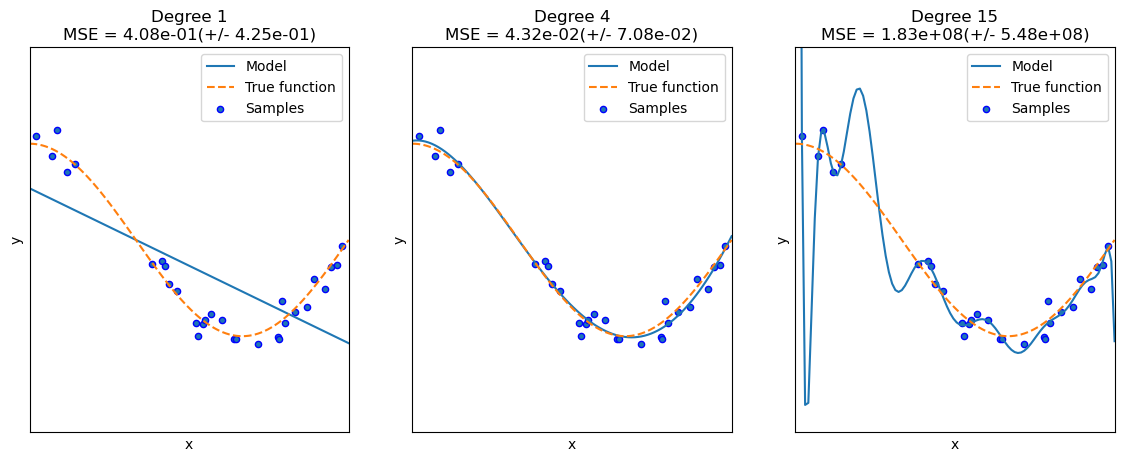

In [25]:
plt.figure(figsize=(14, 5))
degrees = [1, 4, 15]

# 다항 회귀의 차수(degree)를 1, 4, 15로 각각 변화시키면서 비교합니다.
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())
    
    # 개별 degree별로 Polynomial 변환합니다.
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    pipeline.fit(X.reshape(-1, 1), y)
    
    # 교차 검증으로 다항 회귀를 평가합니다.
    scores = cross_val_score(pipeline, X.reshape(-1, 1), y, scoring="neg_mean_squared_error", cv=10)
    # Pipeline을 구성하는 세부 객체를 접근하는 named_steps['객체명']을 이용해 회귀계수 추출
    coefficients = pipeline.named_steps['linear_regression'].coef_
    print('\nDegree {0} 회귀 계수는 {1} 입니다.'.format(degrees[i], np.round(coefficients, 2)))
    print('Degree {0} MSE 는 {1} 입니다.'.format(degrees[i], -1*np.mean(scores)))
          
    # 0 부터 1까지 테스트 데이터 세트를 100개로 나눠 예측을 수행합니다.
    # 테스트 데이터 세트에 회귀 예측을 수행하고 예측 곡선과 실제 곡선을 그려서 비교합니다.
    X_test = np.linspace(0, 1, 100)
    # 예측값 곡선
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    # 실제 값 곡선
    plt.plot(X_test, true_fun(X_test), '--', label="True function")
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")
    plt.xlabel("x"); plt.ylabel("y"); plt.xlim((0, 1)); plt.ylim((-2, 2)); plt.legend(loc="best")
    plt.title("Degree {}\nMSE = {:.2e}(+/- {:.2e})".format(degrees[i], -scores.mean(), scores.std()))
    
plt.show()